In [2]:
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from modules.data_loader import load_data

train_texts, train_labels, test_texts, test_labels, info = load_data("ag_news")
print("Train:", len(train_texts), "Test:", len(test_texts))

Train: 120000 Test: 7600


In [3]:
import pandas as pd

df_train = pd.DataFrame({"text": train_texts, "label": train_labels})
df_test  = pd.DataFrame({"text": test_texts, "label": test_labels})

df_train.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


Num classes: 4
label
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64


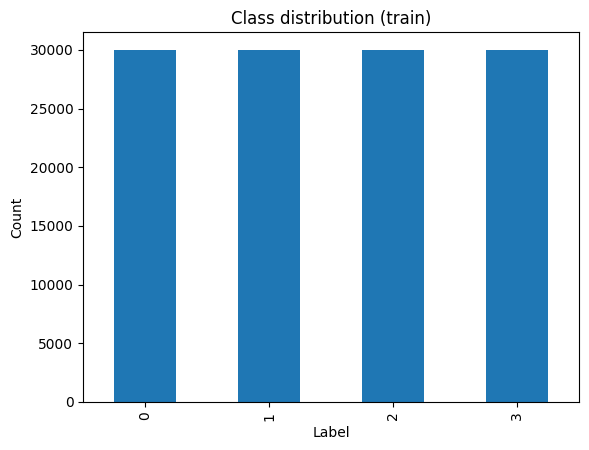

In [4]:
import matplotlib.pyplot as plt

label_counts = df_train["label"].value_counts().sort_index()
print("Num classes:", df_train["label"].nunique())
print(label_counts)

plt.figure()
label_counts.plot(kind="bar")
plt.title("Class distribution (train)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

           len_chars      len_words
count  120000.000000  120000.000000
mean      236.477525      37.847450
std        66.509741      10.085245
min       100.000000       8.000000
25%       196.000000      32.000000
50%       232.000000      37.000000
75%       266.000000      43.000000
max      1012.000000     177.000000


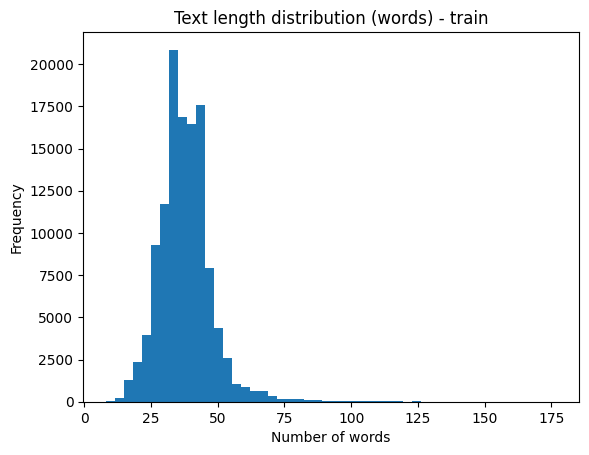

In [5]:
df_train["len_chars"] = df_train["text"].astype(str).str.len()
df_train["len_words"] = df_train["text"].astype(str).str.split().str.len()

print(df_train[["len_chars","len_words"]].describe())

plt.figure()
df_train["len_words"].plot(kind="hist", bins=50)
plt.title("Text length distribution (words) - train")
plt.xlabel("Number of words")
plt.show()

In [6]:
print("Missing text:", df_train["text"].isna().sum())
print("Missing label:", df_train["label"].isna().sum())

dup_count = df_train.duplicated(subset=["text", "label"]).sum()
print("Duplicate rows (text+label):", dup_count)

Missing text: 0
Missing label: 0
Duplicate rows (text+label): 0


In [7]:
for lbl in sorted(df_train["label"].unique()):
    print(f"\n=== Label {lbl} samples ===")
    print(df_train[df_train["label"] == lbl]["text"].head(3).to_list())


=== Label 0 samples ===
['Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\\and in large numbers on Sunday to vote in a historic referendum\\that will either remove left-wing President Hugo Chavez from\\office or give him a new mandate to govern for the next two\\years.', 'S.Koreans Clash with Police on Iraq Troop Dispatch (Reuters) Reuters - South Korean police used water cannon in\\central Seoul Sunday to disperse at least 7,000 protesters\\urging the government to reverse a controversial decision to\\send more troops to Iraq.', "Palestinians in Israeli Jails Start Hunger Strike (Reuters) Reuters - Thousands of Palestinian\\prisoners in Israeli jails began a hunger strike for better\\conditions Sunday, but Israel's security minister said he\\didn't care if they starved to death."]

=== Label 1 samples ===
["Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle s